<a href="https://colab.research.google.com/github/siddikha1234/ELiteTEch-Intern/blob/main/TASK.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset Shape: (150, 4)

Accuracy: 1.0

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



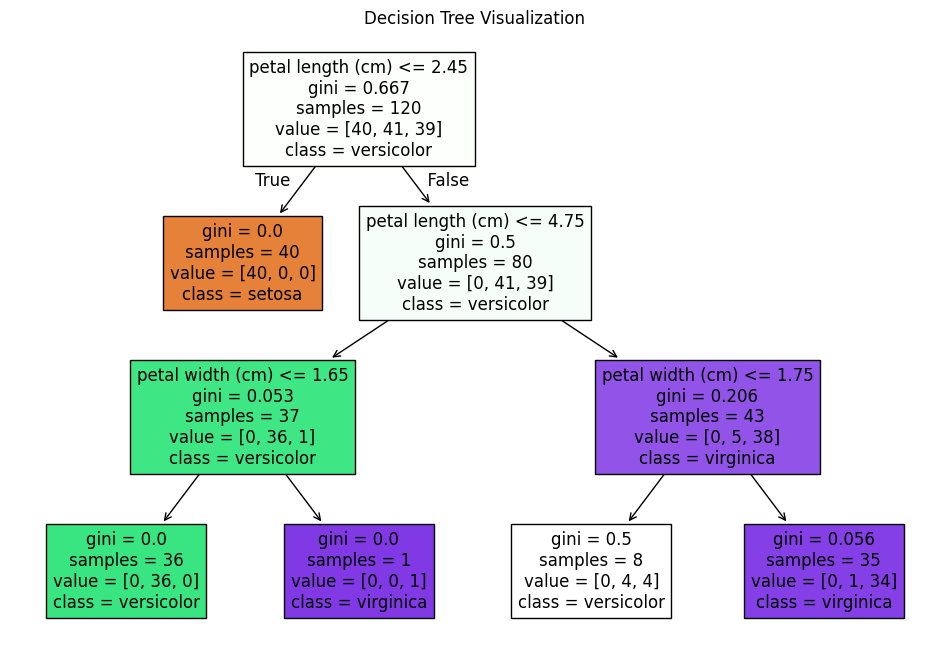


Analysis:
- Decision Tree successfully classifies Iris species.
- Petal measurements are important decision factors.
- Limiting tree depth helps reduce overfitting.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report
iris = load_iris()

X = iris.data
y = iris.target

feature_names = iris.feature_names
class_names = iris.target_names

print("Dataset Shape:", X.shape)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
model = DecisionTreeClassifier(max_depth=3, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("\nAccuracy:", accuracy)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))
plt.figure(figsize=(12, 8))
plot_tree(
    model,
    feature_names=feature_names,
    class_names=class_names,
    filled=True
)
plt.title("Decision Tree Visualization")
plt.show()
print("\nAnalysis:")
print("- Decision Tree successfully classifies Iris species.")
print("- Petal measurements are important decision factors.")
print("- Limiting tree depth helps reduce overfitting.")

In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import re
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')
data = {
    "review": [
        "This product is amazing and works great",
        "Worst purchase I ever made",
        "Very happy with the quality",
        "Terrible experience, not recommended",
        "Excellent performance and good value",
        "Completely useless item",
        "Loved it, will buy again",
        "Waste of money",
        "Very satisfied with the service",
        "Bad quality and poor performance"
    ],
    "sentiment": [1,0,1,0,1,0,1,0,1,0]
}

df = pd.DataFrame(data)
stop_words = set(stopwords.words('english'))

def preprocess(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return " ".join(words)

df["clean_review"] = df["review"].apply(preprocess)
X_train, X_test, y_train, y_test = train_test_split(
    df["clean_review"],
    df["sentiment"],
    test_size=0.2,
    random_state=42
)
vectorizer = TfidfVectorizer()
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)
model = LogisticRegression()
model.fit(X_train_tfidf, y_train)
y_pred = model.predict(X_test_tfidf)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
sample_review = ["The product quality is excellent and amazing"]
sample_clean = [preprocess(r) for r in sample_review]
sample_vec = vectorizer.transform(sample_clean)
prediction = model.predict(sample_vec)

print("\nSample Review Prediction:",
      "Positive" if prediction[0]==1 else "Negative")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Accuracy: 0.5

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.50      1.00      0.67         1

    accuracy                           0.50         2
   macro avg       0.25      0.50      0.33         2
weighted avg       0.25      0.50      0.33         2


Confusion Matrix:
 [[0 1]
 [0 1]]

Sample Review Prediction: Positive


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Training data shape: (50000, 32, 32, 3)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 70s 43ms/step - accuracy: 0.4465 - loss: 1.5250 - val_accuracy: 0.5532 - val_loss: 1.2453
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 84s 45ms/step - accuracy: 0.5870 - loss: 1.1697 - val_accuracy: 0.6145 - val_loss: 1.0906
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 66s 42ms/step - accuracy: 0.6415 - loss: 1.0231 - val_accuracy: 0.6471 - val_loss: 1.0059
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 42ms/step - accuracy: 0.6762 - loss: 0.9218 - val_accuracy: 0.6656 - val_loss: 0.9448
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 83s 43ms/step - accuracy: 0.7029 - loss: 0.8487 - val_accuracy: 0.6799 - val_loss: 0.9270
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 43ms/step - accuracy: 0.7249 - loss: 0.7890 - val_accuracy: 0.6868 - val_loss: 0.9157
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 70s 45ms/step - accuracy: 0.7398 - loss: 0.7436 - val_accuracy: 0.7067 - val_loss: 0.8531
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 69s 44ms/step - accuracy: 0.7548 -

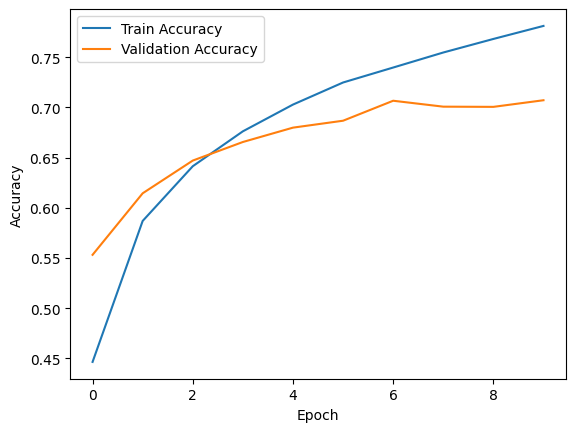

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step

Sample Prediction: cat


In [3]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()
train_images = train_images / 255.0
test_images = test_images / 255.0
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']
print("Training data shape:", train_images.shape)
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10)
])
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)
history = model.fit(
    train_images, train_labels,
    epochs=10,
    validation_data=(test_images, test_labels)
)
test_loss, test_acc = model.evaluate(test_images, test_labels)
print("\nTest Accuracy:", test_acc)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()
probability_model = tf.keras.Sequential([model, layers.Softmax()])
predictions = probability_model.predict(test_images)
print("\nSample Prediction:", class_names[predictions[0].argmax()])

Training data shape: (50000, 32, 32, 3)
Test data shape: (10000, 32, 32, 3)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 70s 43ms/step - accuracy: 0.4491 - loss: 1.5115 - val_accuracy: 0.5476 - val_loss: 1.2418
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 69s 44ms/step - accuracy: 0.5855 - loss: 1.1641 - val_accuracy: 0.6193 - val_loss: 1.0887
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 80s 43ms/step - accuracy: 0.6459 - loss: 1.0090 - val_accuracy: 0.6518 - val_loss: 0.9944
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 69s 44ms/step - accuracy: 0.6825 - loss: 0.9129 - val_accuracy: 0.6577 - val_loss: 0.9819
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 80s 43ms/step - accuracy: 0.7008 - loss: 0.8513 - val_accuracy: 0.6787 - val_loss: 0.9139
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 43ms/step - accuracy: 0.7231 - loss: 0.7967 - val_accuracy: 0.6935 - val_loss: 0.8859
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 83s 44ms/step - accuracy: 0.7388 - loss: 0.7451 - val_accuracy: 0.7053 - val_loss: 0.8568
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 80s 43ms/step - accuracy: 0.7486 -

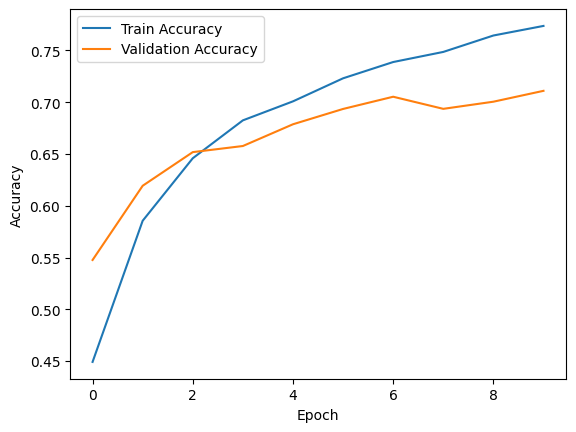

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step


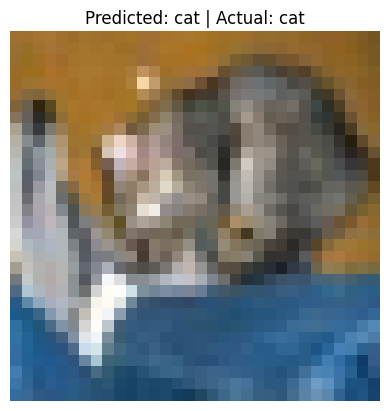

Model saved successfully!


In [4]:
# ============================================
# IMAGE CLASSIFICATION USING CNN (TENSORFLOW)
# ============================================

# Step 1: Import Required Libraries
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np

# ============================================
# Step 2: Load Dataset (CIFAR-10)
# ============================================
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Normalize pixel values
x_train = x_train / 255.0
x_test = x_test / 255.0

print("Training data shape:", x_train.shape)
print("Test data shape:", x_test.shape)

# ============================================
# Step 3: Define Class Names
# ============================================
class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

# ============================================
# Step 4: Build CNN Model
# ============================================
model = models.Sequential()

model.add(layers.Conv2D(32, (3,3), activation='relu',
                         input_shape=(32,32,3)))
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Conv2D(64, (3,3), activation='relu'))
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Conv2D(64, (3,3), activation='relu'))

model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10, activation='softmax'))

model.summary()

# ============================================
# Step 5: Compile Model
# ============================================
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# ============================================
# Step 6: Train Model
# ============================================
history = model.fit(
    x_train, y_train,
    epochs=10,
    validation_data=(x_test, y_test)
)

# ============================================
# Step 7: Evaluate Model
# ============================================
test_loss, test_acc = model.evaluate(x_test, y_test)
print("\nTest Accuracy:", test_acc)

# ============================================
# Step 8: Plot Accuracy Graph
# ============================================
plt.figure()
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# ============================================
# Step 9: Predictions Example
# ============================================
predictions = model.predict(x_test)

def show_prediction(index):
    plt.imshow(x_test[index])
    plt.title("Predicted: {} | Actual: {}".format(
        class_names[np.argmax(predictions[index])],
        class_names[y_test[index][0]]
    ))
    plt.axis('off')
    plt.show()

# Show sample prediction
show_prediction(0)

# ============================================
# Step 10: Save Model
# ============================================
model.save("cnn_image_classifier.h5")
print("Model saved successfully!")